In [ ]:
%reload_ext autoreload
%autoreload 2
import mujoco
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

sim = MiniprojectSimulation(level=3, seed=46)
controller = Controller(sim)

thorax_id = mujoco.mj_name2id(sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, f"{sim.fly.name}/c_thorax")

vision_signal = []
olfactory_signal = []
wind_signal = []
wind_direction = []
fly_thorax_quat = []
for _ in trange(20000): #10000
    joint_angles, adhesion = controller.step(sim)
    vision_signal.append(controller.vision.current_signal)
    olfactory_signal.append(controller.olfaction.current_signal)
    wind_signal.append(controller.wind.current_signal)
    wind_direction.append(sim.mj_model.opt.wind[:2].copy())
    fly_thorax_quat.append(sim.mj_data.xquat[thorax_id].copy())  # [w, x, y, z]
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()

100%|██████████| 20000/20000 [00:26<00:00, 748.21it/s]


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

vision_signal = np.asarray(vision_signal)
olfactory_signal = np.asarray(olfactory_signal)
wind_signal = np.asarray(wind_signal)
wind_direction = np.asarray(wind_direction)        # shape (T, 2): [wind_x, wind_y] in world frame
fly_thorax_quat = np.asarray(fly_thorax_quat)      # shape (T, 4): [w, x, y, z]

x = np.arange(len(vision_signal))

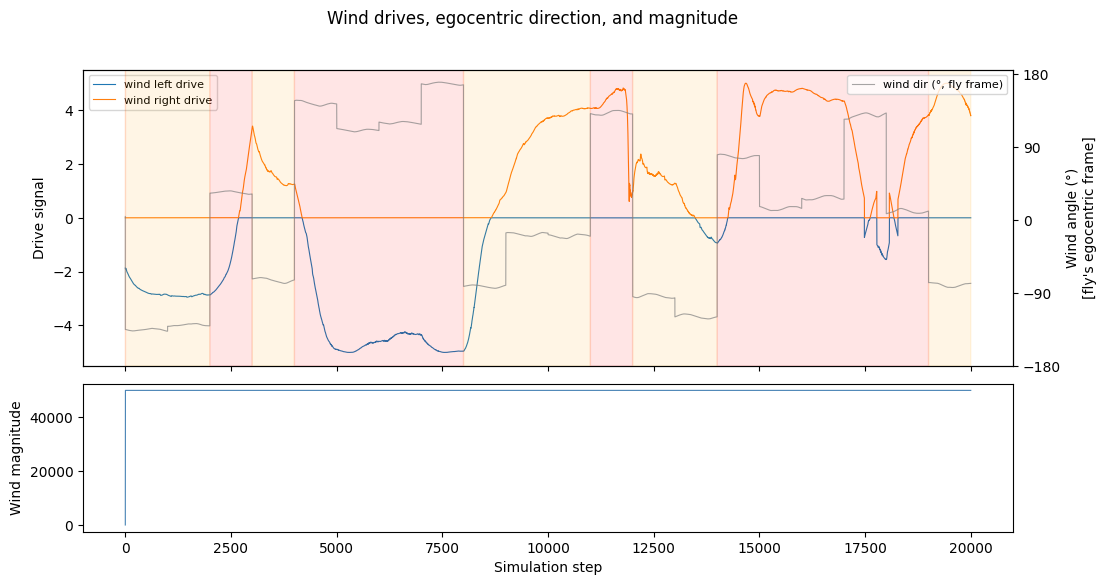

In [3]:
from matplotlib.gridspec import GridSpec

# World-frame wind angle and magnitude from MuJoCo opt.wind
wind_angle_world = np.arctan2(wind_direction[:, 1], wind_direction[:, 0])
wind_magnitude   = np.linalg.norm(wind_direction, axis=1)

# Fly heading (yaw) extracted from thorax quaternion [w, x, y, z]
w, x_, y_, z_ = fly_thorax_quat[:, 0], fly_thorax_quat[:, 1], fly_thorax_quat[:, 2], fly_thorax_quat[:, 3]
fly_yaw = np.arctan2(2 * (w * z_ + x_ * y_), 1 - 2 * (y_**2 + z_**2))

# Wind angle in fly's egocentric frame (wrapped to [-180, 180])
egocentric_wind_angle = np.degrees(np.arctan2(
    np.sin(wind_angle_world - fly_yaw),
    np.cos(wind_angle_world - fly_yaw),
))

fig = plt.figure(figsize=(12, 6))
gs  = GridSpec(2, 1, figure=fig, hspace=0.08, height_ratios=[2, 1])

# ── top panel: drives + egocentric angle ──────────────────────────────
ax1  = fig.add_subplot(gs[0])
ax1b = ax1.twinx()

ax1.plot(x, wind_signal[:, 0], label='wind left drive',  lw=0.8)
ax1.plot(x, wind_signal[:, 1], label='wind right drive', lw=0.8)
ax1.set_ylabel('Drive signal')
ax1.legend(loc='upper left', fontsize=8)
ax1.tick_params(labelbottom=False)

t = ax1b.get_xaxis_transform()
ax1b.fill_between(x, 0, 1, where=egocentric_wind_angle < 0,  alpha=0.1, color='orange', transform=t)
ax1b.fill_between(x, 0, 1, where=egocentric_wind_angle >= 0, alpha=0.1, color='red',    transform=t)
ax1b.plot(x, egocentric_wind_angle, color='gray', alpha=0.7, lw=0.8, label='wind dir (°, fly frame)')
ax1b.set_ylabel("Wind angle (°)\n[fly's egocentric frame]")
ax1b.set_yticks([-180, -90, 0, 90, 180])
ax1b.legend(loc='upper right', fontsize=8)

# ── bottom panel: wind magnitude ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(x, wind_magnitude, color='steelblue', lw=0.8)
ax2.set_ylabel('Wind magnitude')
ax2.set_xlabel('Simulation step')

fig.suptitle('Wind drives, egocentric direction, and magnitude')
plt.show()

/var/folders/7z/392mmwys43l8y6c7ym46p13w0000gn/T/ipykernel_84462/1454530197.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


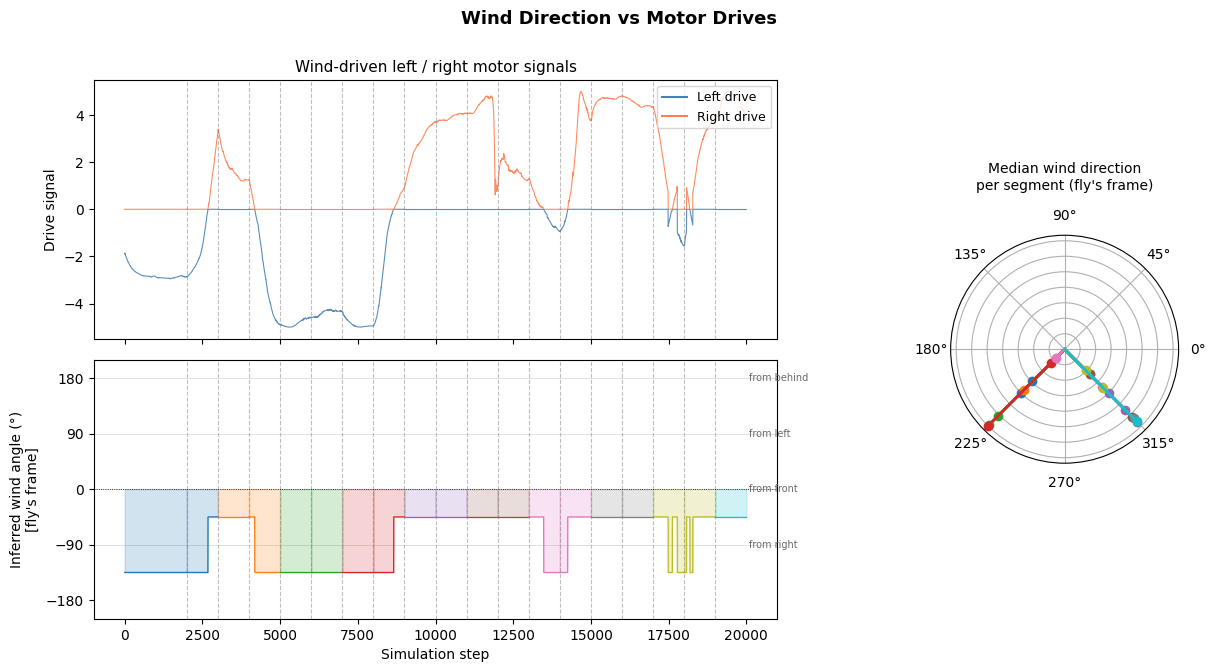

In [4]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import numpy as np

wind_arr = np.asarray(wind_signal)

# Derive directional components from the drive signals (fly's egocentric frame):
#   lateral = left - right  →  asymmetry encodes sideways wind component
#   forward = left + right  →  sum encodes head-on / tail-wind component
#   inferred angle = atan2(lateral, forward)  →  wind bearing in fly's frame
lateral = wind_arr[:, 0] - wind_arr[:, 1]
forward = wind_arr[:, 0] + wind_arr[:, 1]
inferred_angle_deg = np.degrees(np.arctan2(lateral, forward))

# Wind changes every 1000 steps at step >= 2000 (see simulation.py MiniprojectSimulation.step)
n_steps = len(wind_arr)
wind_change_steps = list(range(2000, n_steps, 1000))
segment_edges = [0] + wind_change_steps + [n_steps]
n_segs = len(segment_edges) - 1
seg_colors = plt.cm.tab10(np.linspace(0, 0.9, n_segs))

fig = plt.figure(figsize=(14, 7))
gs = GridSpec(2, 2, figure=fig, width_ratios=[3, 1], hspace=0.08, wspace=0.38)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[:, 1], projection='polar')

# --- Left panels: time series, one color per wind segment ---
for i, (s, e) in enumerate(zip(segment_edges[:-1], segment_edges[1:])):
    sl = slice(int(s), int(e))
    ax1.plot(x[sl], wind_arr[sl, 0], color='steelblue', lw=0.8, alpha=0.9)
    ax1.plot(x[sl], wind_arr[sl, 1], color='coral',     lw=0.8, alpha=0.9)
    ax2.fill_between(x[sl], inferred_angle_deg[sl], alpha=0.2, color=seg_colors[i])
    ax2.plot(x[sl], inferred_angle_deg[sl], color=seg_colors[i], lw=0.9)

# Vertical dashed lines at each wind-change event
for step in wind_change_steps:
    ax1.axvline(step, color='gray', ls='--', alpha=0.5, lw=0.8)
    ax2.axvline(step, color='gray', ls='--', alpha=0.5, lw=0.8)

ax1.set_ylabel('Drive signal')
ax1.set_title('Wind-driven left / right motor signals', fontsize=11)
ax1.legend(
    handles=[
        mlines.Line2D([], [], color='steelblue', label='Left drive'),
        mlines.Line2D([], [], color='coral',     label='Right drive'),
    ],
    loc='upper right', fontsize=9,
)
ax1.tick_params(labelbottom=False)

# Reference lines for cardinal wind directions
for angle, label in [(-90, 'from right'), (0, 'from front'), (90, 'from left'), (180, 'from behind')]:
    ax2.axhline(angle, color='lightgray', lw=0.5, zorder=0)
    ax2.text(n_steps * 1.005, angle, label, fontsize=7, va='center', color='dimgray')
ax2.axhline(0, color='black', lw=0.6, ls=':')
ax2.set_ylabel("Inferred wind angle (°)\n[fly's frame]")
ax2.set_xlabel('Simulation step')
ax2.set_yticks([-180, -90, 0, 90, 180])
ax2.set_ylim(-210, 210)

# --- Right panel: polar rose — one arrow per wind segment ---
for i, (s, e) in enumerate(zip(segment_edges[:-1], segment_edges[1:])):
    sl = slice(int(s), int(e))
    med_angle = np.median(inferred_angle_deg[sl])
    med_r     = np.median(np.hypot(lateral[sl], forward[sl]))
    theta = np.radians(med_angle)
    ax3.plot([0, theta], [0, med_r], '-', color=seg_colors[i], lw=2)
    ax3.plot(theta, med_r, 'o', color=seg_colors[i], ms=6)

ax3.set_yticklabels([])
ax3.set_title("Median wind direction\nper segment (fly's frame)", pad=14, fontsize=10)

fig.suptitle("Wind Direction vs Motor Drives", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


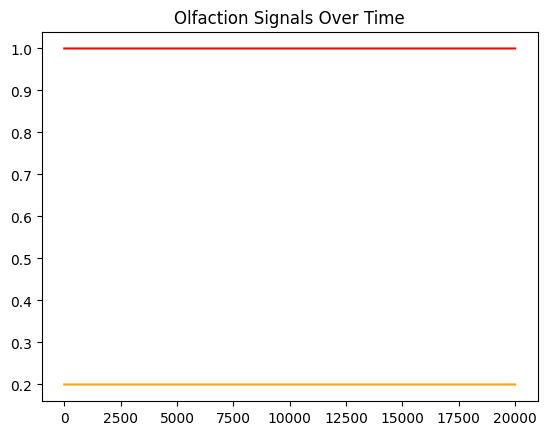

In [22]:
plt.figure()
plt.plot(x, olfactory_signal[:,0], color="orange", label="smell left drive")
plt.plot(x, olfactory_signal[:,1], color="red", label="smell right drive")
plt.title("Olfaction Signals Over Time")
plt.show()

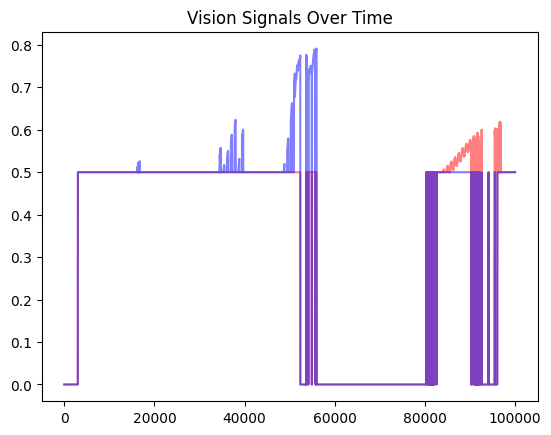

In [5]:
plt.figure()
plt.plot(x, vision_signal[:,0], color="red", label="vision left drive", alpha=0.5)
plt.plot(x, vision_signal[:,1], color="blue", label="vision right drive", alpha=0.5)
#plt.plot(x, np.abs(vision_signal[:,1] - vision_signal[:,0]), color="red", label="vision right drive")
plt.title("Vision Signals Over Time")
plt.show()

In [ ]:
controller.olfaction.olfaction_smooth, sim.get_olfaction(sim.fly.name)

(array([[3.02365859e-08],
        [2.77959536e-08],
        [2.76207044e-08],
        [2.71062224e-08]]),
 array([[3.04457004e-08],
        [2.79823251e-08],
        [2.78146843e-08],
        [2.72956509e-08]]))

In [ ]:
sim.get_antenna_data(sim.fly.name).keys()

dict_keys(['l', 'r'])

In [ ]:
sim.get_antenna_data(sim.fly.name)['l'].keys()

dict_keys(['qpos', 'qvel', 'qacc', 'qfrc_passive'])

In [ ]:
sim.get_antenna_data(sim.fly.name)['l']['qvel']

array([-0.12694573, -0.09150428, -0.02246473])